In [1]:
%run ../../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [4]:
from src.data.dataset_builder import DatasetBuilder, assign_task_labels
from src.features.feature_extractor import FeatureExtractor
from src.data.dataset import KidneyStoneDataset
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor
import pandas as pd
from src.pipelines.xgboost_pipeline import XGBoostExperiment
builder = DatasetBuilder(root_path= DATASET_PATH_XGBOOST)
lbp = LocalBinaryPattern(numPoints=NUMPOINTS, radius=RADIUS)
hsv = HSV_extractor(n_bins=N_BINS)
extractor = FeatureExtractor(hsv, lbp)


In [4]:
results= []

patches_df_full = pd.read_csv(f"experiments/patches_{PATCH_SIZE}_metadata.csv")

task_name = "multiclase"
task_config = TASKS[task_name]

patches_task = assign_task_labels(patches_df_full, task_config)
xgboost_model= XGBoostExperiment(patches_task, extractor, Case.PATCH)


  Features shape: (5290, 40)
  Distribución: {0: 2767, 1: 298, 2: 1372, 3: 485, 4: 368}


In [7]:

print(f"  patches: {len(patches_task)}")
print(f"  imágenes: {patches_task['source_image'].nunique()}")
print(f"  distribución: {patches_task['label'].value_counts().to_dict()}")

config = {
    "name": f"patches_xgboost_{task_name}",
    "output_dir": f"experiments/xgboost/xgboost_patches/patches_xgboost_{task_name}_no_augmentation",
    "class_names": task_config["class_names"],
}
result_multi= xgboost_model.search_hyperparameters(config)



  patches: 5290
  imágenes: 396
  distribución: {0: 2767, 2: 1372, 3: 485, 4: 368, 1: 298}

BÚSQUEDA HP: patches_xgboost_multiclase
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.5296
  Best params: {'max_depth': 9, 'min_child_weight': 10, 'n_estimators': 442, 'learning_rate': 0.030594482322576156, 'subsample': 0.5757403143052913, 'colsample_bytree': 0.9991375134009548}



EVALUACIÓN CV: patches_xgboost_multiclase (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.6706 | precision_weighted=0.6931 | recall_weighted=0.6706 | f1_weighted=0.6706 | auc_weighted=0.8512
  Fold 2: accuracy=0.6876 | precision_weighted=0.6768 | recall_weighted=0.6876 | f1_weighted=0.6691 | auc_weighted=0.8857
  Fold 3: accuracy=0.7103 | precision_weighted=0.7034 | recall_weighted=0.7103 | f1_weighted=0.6934 | auc_weighted=0.8669
  Fold 4: accuracy=0.6192 | precision_weighted=0.6532 | recall_weighted=0.6192 | f1_weighted=0.6026 | auc_weighted=0.8348
  Fold 5: accuracy=0.6224 | precision_weighted=0.6592 | recall_weighted=0.6224 | f1_weighted=0.6162 | auc_weighted=0.8106

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6620 ± 0.0360
  auc_weighted: 0.8498 ± 0.0259
  f1_weighted: 0.6504 ± 0.0348
  precision_weighted: 0.6771 ± 0.0192
  recall_weighted: 0.6620 ± 0.0360


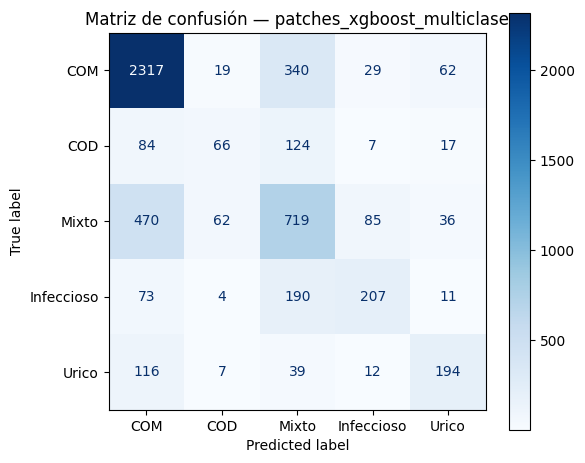


 Métricas agregadas a nivel imagen (media ± std entre folds):

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.7131 ± 0.0478
  auc_weighted: 0.8920 ± 0.0392
  f1_weighted: 0.6863 ± 0.0529
  precision_weighted: 0.7049 ± 0.0564
  recall_weighted: 0.7131 ± 0.0478


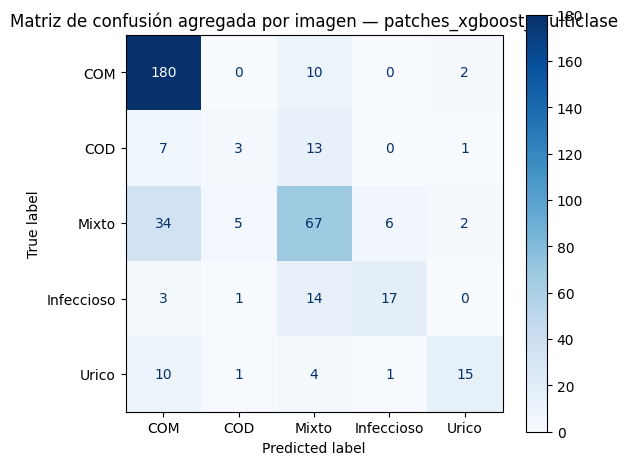

In [9]:
eval_result= xgboost_model.evaluate_cv(config, result_multi["best_params"],show_fold_metrics= True)
results.append(eval_result)

IMBALANCED

Tras genenrar nuevos patches, vamos a usarlos para nuestra clasificacion

In [5]:
patches_df_full = pd.read_csv("experiments/patches_320/multiclass_metadata_balanced.csv")
task_name = "multiclase"
task_config = TASKS[task_name]

patches_task = assign_task_labels(patches_df_full, task_config)


config = {
"name": f"xgboost_patches_{task_name}_augmented",
"output_dir": f"experiments/xgboost/xgboost_patches/xgboost_{task_name}_with_augmentation",
"class_names": task_config["class_names"],
}

model = XGBoostExperiment(patches_task, extractor, Case.PATCH)
result= model.search_hyperparameters(config)



  Features shape: (13835, 40)
  Distribución: {0: 2767, 1: 2767, 2: 2767, 3: 2767, 4: 2767}

BÚSQUEDA HP: xgboost_patches_multiclase_augmented
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.5431
  Best params: {'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 560, 'learning_rate': 0.02686027344083065, 'subsample': 0.7104054940950494, 'colsample_bytree': 0.7869985836600174}



EVALUACIÓN CV: xgboost_patches_multiclase_augmented (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.6303 | precision_weighted=0.6631 | recall_weighted=0.6303 | f1_weighted=0.6428 | auc_weighted=0.8679
  Fold 2: accuracy=0.5198 | precision_weighted=0.5567 | recall_weighted=0.5198 | f1_weighted=0.5130 | auc_weighted=0.7903
  Fold 3: accuracy=0.5139 | precision_weighted=0.5595 | recall_weighted=0.5139 | f1_weighted=0.5191 | auc_weighted=0.8304
  Fold 4: accuracy=0.5442 | precision_weighted=0.5603 | recall_weighted=0.5442 | f1_weighted=0.5486 | auc_weighted=0.8255
  Fold 5: accuracy=0.5288 | precision_weighted=0.5467 | recall_weighted=0.5288 | f1_weighted=0.5235 | auc_weighted=0.8283

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.5474 ± 0.0427
  auc_weighted: 0.8285 ± 0.0246
  f1_weighted: 0.5494 ± 0.0483
  precision_weighted: 0.5772 ± 0.0432
  recall_weighted: 0.5474 ± 0.0427


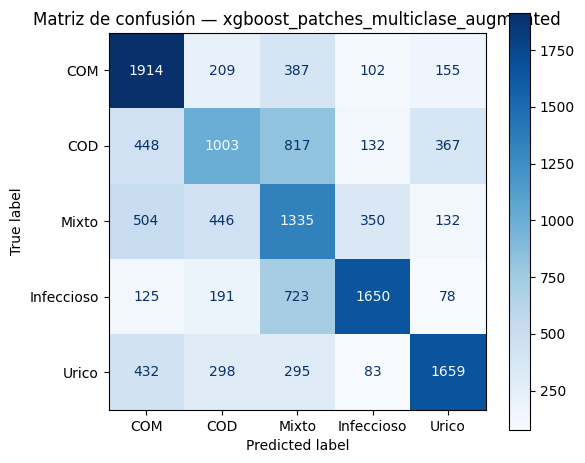


 Métricas agregadas a nivel imagen (media ± std entre folds):

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6935 ± 0.0285
  auc_weighted: 0.8889 ± 0.0118
  f1_weighted: 0.6998 ± 0.0247
  precision_weighted: 0.7308 ± 0.0339
  recall_weighted: 0.6935 ± 0.0285


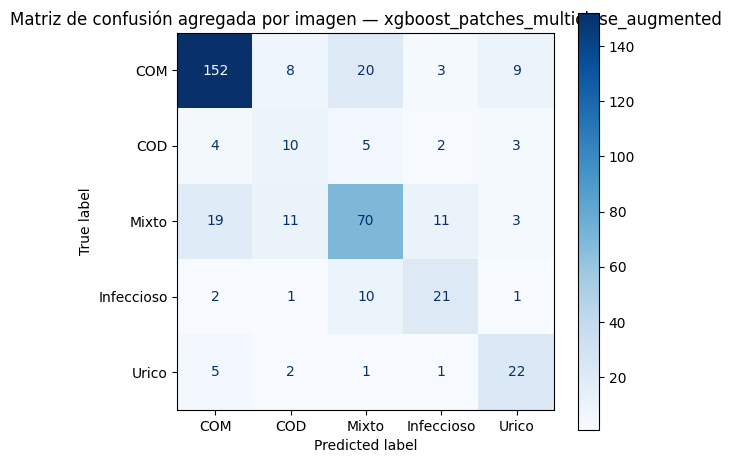

In [7]:
eval_result= model.evaluate_cv(config, result["best_params"], show_fold_metrics= True)
# results.append(eval_result)